### IMPORTING NECESSARY LIBRARIES

In [127]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [128]:
df = pd.read_csv(r"C:\Users\LAVANYA SINGH\OneDrive\Desktop\MC MASTER UNIVERSITY\Big Data\breast cancer _data.csv")

In [129]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# MISSING VALUES

In [130]:
#checking whether there dataset has any null values or not 
df.isnull().sum().sum()

0

# ASSIGNING BINARY VALUES TO MALIGNANT AND NON MALIGNANT CASES

In [131]:
df['diagnosis']=df['diagnosis'].map({'M':1,'B':0})
df.diagnosis.value_counts()

0    357
1    212
Name: diagnosis, dtype: int64

In [132]:
X=df.iloc[:,[2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]]
y=df.diagnosis.values

# CORRELATION OF PARAMETERS WITH RESPECT TO DIAGNOSIS

In [133]:
correlation_matrix = df.corr()
target_correlation = correlation_matrix['diagnosis'].abs().sort_values(ascending=False).index
correlation_matrix = correlation_matrix.loc[target_correlation, target_correlation]

In [134]:
correlation_matrix

,diagnosis,concave_points_worst,perimeter_worst,concave_points_mean,radius_worst,perimeter_mean,area_worst,radius_mean,area_mean,concavity_mean,...,symmetry_mean,fractal_dimension_worst,compactness_se,concavity_se,fractal_dimension_se,smoothness_se,id,fractal_dimension_mean,texture_se,symmetry_se
diagnosis,1.000000,0.793566,0.782914,0.776614,0.776454,0.742636,0.733825,0.730029,0.708984,0.696360,...,0.330499,0.323872,0.292999,0.253730,0.077972,-0.067016,0.039769,-0.012838,-0.008303,-0.006522
concave_points_worst,0.793566,1.000000,0.816322,0.910155,0.787424,0.771241,0.747419,0.744214,0.722017,0.861323,...,0.430297,0.511114,0.483208,0.440472,0.215204,-0.102007,0.035174,0.175325,-0.119638,-0.030413
perimeter_worst,0.782914,0.816322,1.000000,0.855923,0.993708,0.970387,0.977578,0.965137,0.959120,0.729565,...,0.219169,0.138957,0.260516,0.226680,-0.001000,-0.217304,0.079986,-0.205151,-0.102242,-0.103753
concave_points_mean,0.776614,0.910155,0.855923,1.000000,0.830318,0.850977,0.809630,0.822529,0.823269,0.921391,...,0.462497,0.368661,0.490424,0.439167,0.257584,0.027653,0.044158,0.166917,0.021480,0.095351
radius_worst,0.776454,0.787424,0.993708,0.830318,1.000000,0.969476,0.984015,0.969539,0.962746,0.688236,...,0.185728,0.093492,0.204607,0.186904,-0.037488,-0.230691,0.082405,-0.253691,-0.111690,-0.128121
perimeter_mean,0.742636,0.771241,0.970387,0.850977,0.969476,1.000000,0.941550,0.997855,0.986507,0.716136,...,0.183027,0.051019,0.250744,0.228082,-0.005523,-0.202694,0.073159,-0.261477,-0.086761,-0.081629
area_worst,0.733825,0.747419,0.977578,0.809630,0.984015,0.941550,1.000000,0.941082,0.959213,0.675987,...,0.177193,0.079647,0.199371,0.188353,-0.022736,-0.182195,0.107187,-0.231854,-0.083195,-0.110343
radius_mean,0.730029,0.744214,0.965137,0.822529,0.969539,0.997855,0.941082,1.000000,0.987357,0.676764,...,0.147741,0.007066,0.206000,0.194204,-0.042641,-0.222600,0.074626,-0.311631,-0.097317,-0.104321
area_mean,0.708984,0.722017,0.959120,0.823269,0.962746,0.986507,0.959213,0.987357,1.000000,0.685983,...,0.151293,0.003738,0.212583,0.207660,-0.019887,-0.166777,0.096893,-0.283110,-0.066280,-0.072497
concavity_mean,0.696360,0.861323,0.729565,0.921391,0.688236,0.716136,0.675987,0.676764,0.685983,1.000000,...,0.500667,0.514930,0.670279,0.691270,0.449301,0.098564,0.050080,0.336783,0.076218,0.178009


# HEATMAP

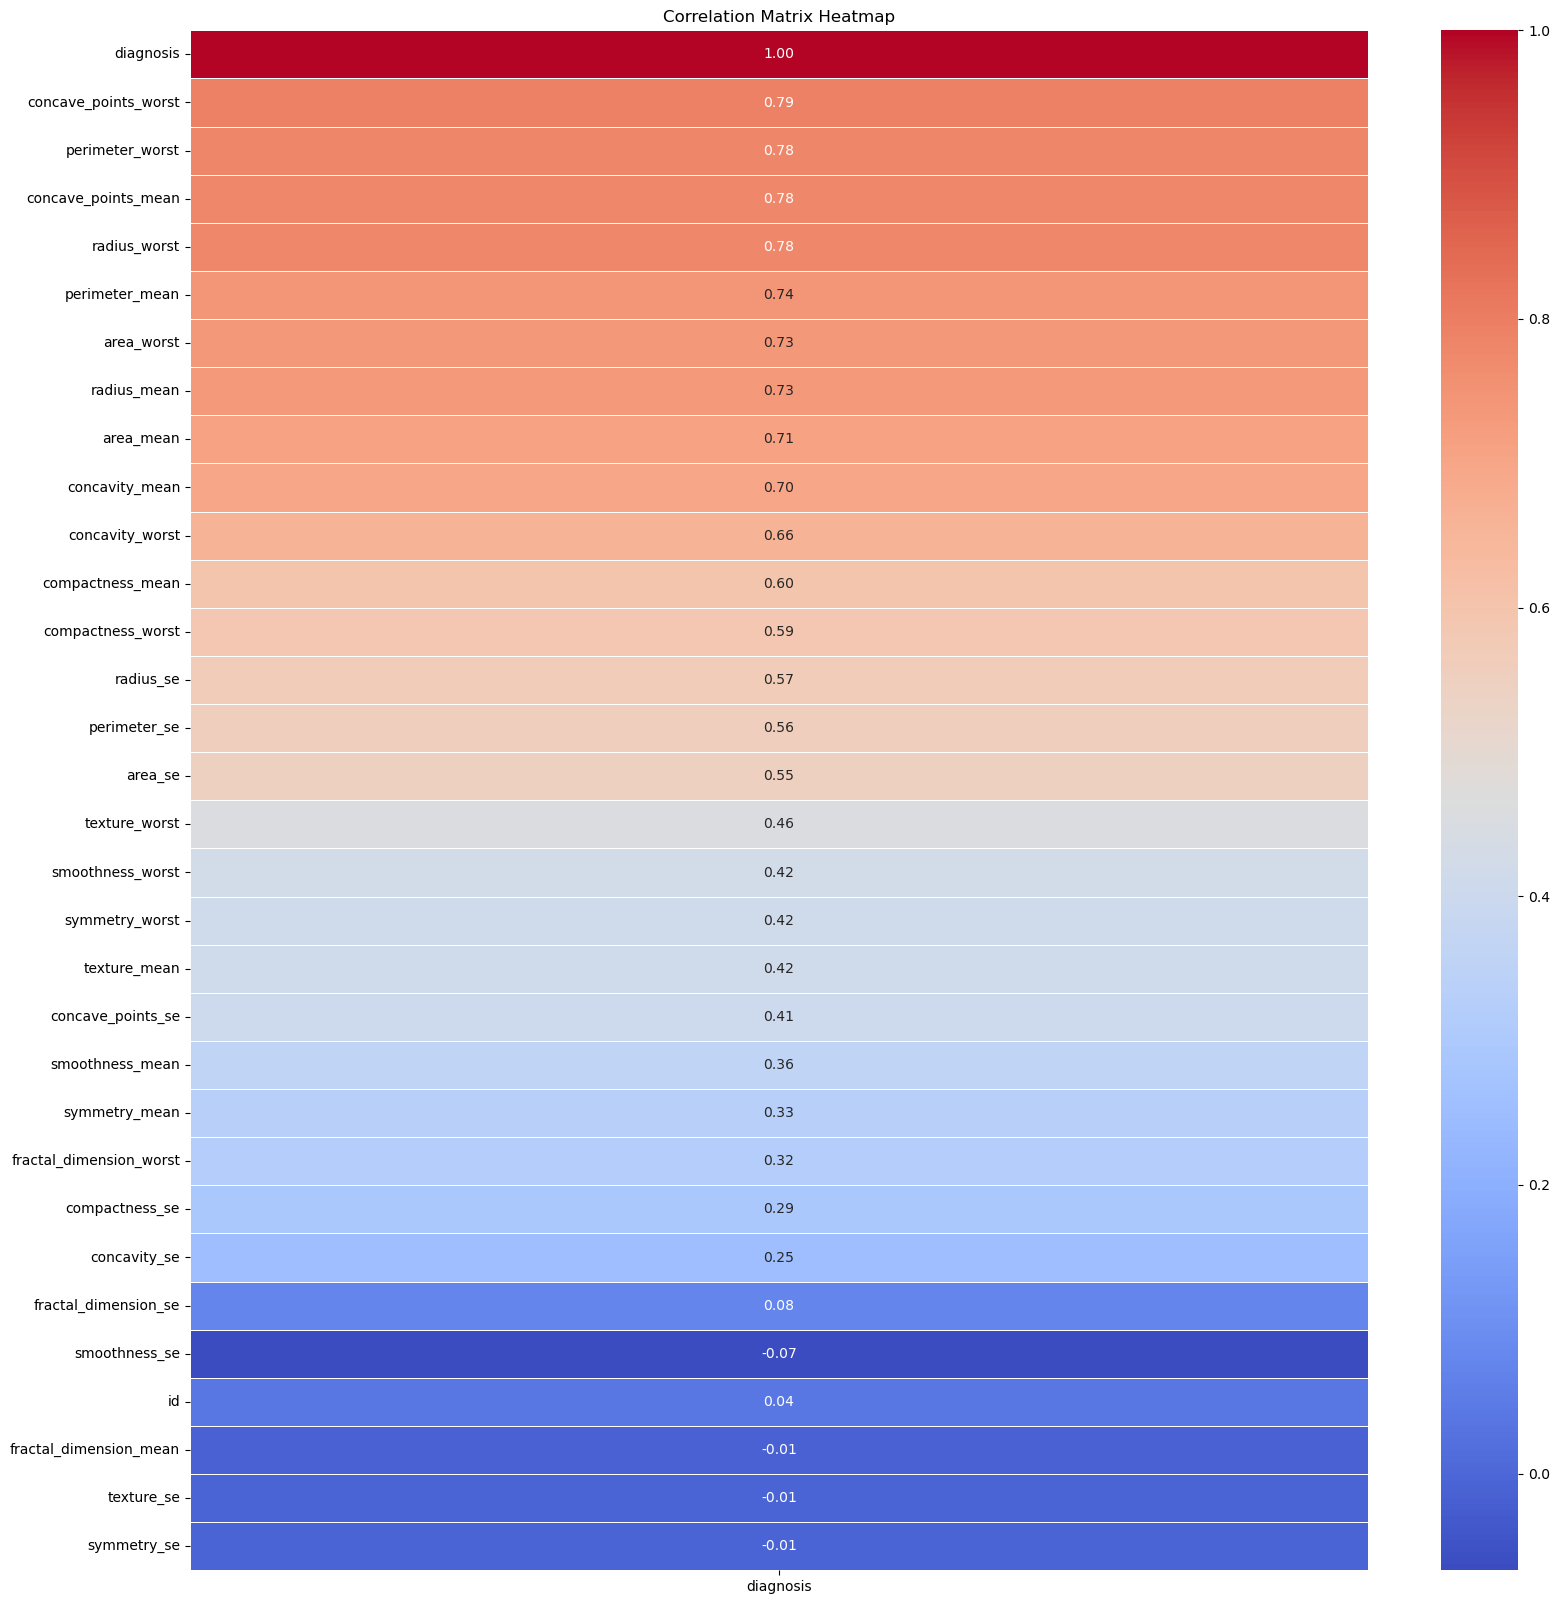

In [135]:
plt.figure(figsize=(19, 20))
sns.heatmap(correlation_matrix[['diagnosis']], annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

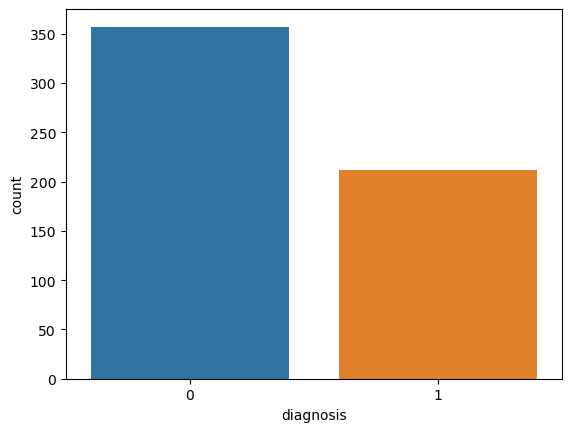

In [136]:
sns.countplot(x='diagnosis',data=df)
plt.show()

# Dataset is not bias towards  any of the unique value of diagnosis

# IMPLEMENTING PCA

In [137]:
#Performing Testing and Training of data 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0)
sc=StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [138]:
n_components = 2
pca = PCA(n_components=n_components)
X_train=pca.fit_transform(X_train)
X_test=pca.fit_transform(X_test)

Text(0, 0.5, 'Second Principal Component')

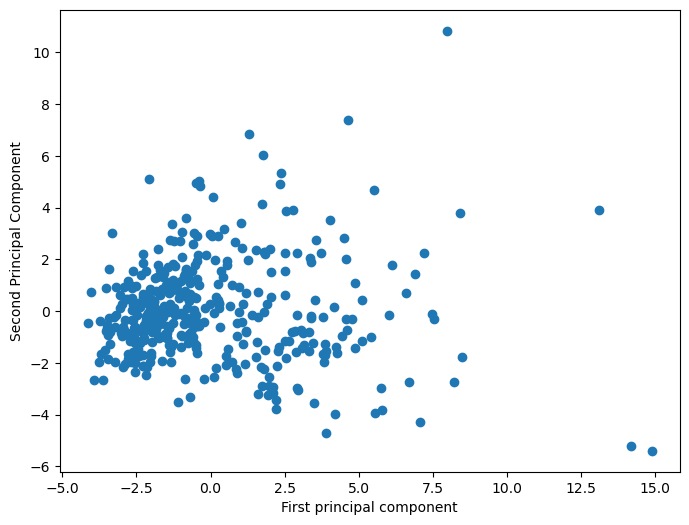

In [139]:
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0],X_train[:,1])
plt.xlabel('First principal component')
plt.ylabel('Second Principal Component')

In [140]:
X_train

array([[-1.85160723,  0.78933335],
       [-2.6325082 ,  0.95679929],
       [-2.10382779, -0.10193046],
       [-0.68710979, -3.30968393],
       [-3.33699808,  3.00930054],
       [-2.76968554,  1.17513464],
       [-1.37249853,  0.28478101],
       [-2.64225361,  0.49522464],
       [-1.33447325, -1.96099344],
       [ 4.60201692, -0.73652401],
       [-2.0342357 ,  0.0962245 ],
       [-1.47461546, -0.83679206],
       [-0.59564002, -0.98798511],
       [-1.88964407,  0.39529486],
       [-1.69975923,  1.57573041],
       [-1.34295292, -1.38176546],
       [-0.82310351,  1.61023019],
       [ 2.89352591, -1.58604118],
       [-3.23086338, -0.61190501],
       [-1.02078102,  2.70464449],
       [ 0.87731461, -2.38590224],
       [ 1.82116836,  2.22407588],
       [-2.08365392,  0.70538304],
       [-0.55233474,  3.01775144],
       [ 4.56421431, -0.30445109],
       [ 7.47599137, -0.11698116],
       [-2.76743282, -0.90536241],
       [-1.52772698, -0.88298069],
       [ 1.15120565,

In [141]:
X_test

array([[ 1.18778493e+00,  4.93199570e-01],
       [-2.56608840e+00, -1.13609420e+00],
       [-2.77822094e+00, -1.39597391e+00],
       [-3.15621616e+00, -1.90504624e+00],
       [-2.31965349e+00, -2.43840336e-01],
       [-1.42560472e+00,  1.16285678e+00],
       [-7.05633968e-01,  6.73285663e-01],
       [-2.60863385e+00,  4.53227580e-01],
       [-2.95272189e+00,  2.49053931e+00],
       [-2.21946945e-01,  4.11293141e+00],
       [ 2.80417822e+00,  1.84268214e+00],
       [-1.31688295e+00, -1.20807503e+00],
       [-2.87176744e+00,  1.10397707e+00],
       [-6.00503704e-01, -2.17661567e+00],
       [ 1.60084910e+00,  3.72198585e-01],
       [ 1.88486161e+00,  9.28686390e-02],
       [ 4.00102276e+00,  5.18024707e+00],
       [ 1.38169511e+00, -3.88200158e+00],
       [ 5.09326085e+00, -6.23983350e-01],
       [ 5.61057203e+00, -2.93323401e+00],
       [ 1.22523389e+00,  1.81309112e+00],
       [ 1.69044249e+00, -7.30203260e-01],
       [-1.42176786e+00,  6.31940155e-02],
       [-2.

In [142]:
explained_variance= pca.explained_variance_ratio_

In [143]:
explained_variance

array([0.45706937, 0.17837395])

In [144]:
np.sum(explained_variance)

0.6354433171589162

# IMPLEMENTING DIFFERENT MACHINE LEARNING MODELS

In [145]:
result_with_outliers={}

# LOGISTIC REGRESSION

In [146]:
#Logistric Regression
from sklearn.linear_model import LogisticRegression
classifier= LogisticRegression(random_state=0)
classifier.fit(X_train,y_train)

LogisticRegression(random_state=0)

In [147]:
#Prediction part
y_pred=classifier.predict(X_test)

In [148]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[98 10]
 [ 7 56]]


<Axes: >

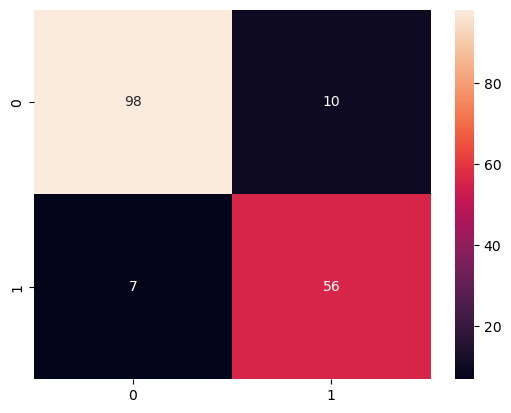

In [149]:
sns.heatmap(cm,annot=True)

In [150]:
from sklearn.metrics import accuracy_score
print('Accuracy: ' +str(accuracy_score(y_test,y_pred)))

Accuracy: 0.9005847953216374


In [151]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f1)

0.8682170542635659


In [152]:
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0], dtype=int64)

In [153]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print(precision)

0.8484848484848485


In [154]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred)
print(recall)

0.8888888888888888


In [155]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')


result_with_outliers["LogisticRegression"]=[{"accuracy":accuracy_score(y_test,y_pred),"f1-score":f1,"precision":precision,"recall":recall,"mae":mean_absolute_error(y_test, y_pred),"mse":mean_squared_error(y_test, y_pred),}]



Mean Absolute Error (MAE): 0.09941520467836257
Mean Squared Error (MSE): 0.09941520467836257


# RANDOM FOREST

In [156]:
from sklearn.ensemble import RandomForestClassifier
randomforest_model = RandomForestClassifier(n_estimators=60, random_state=42)
randomforest_model.fit(X_train, y_train)
y_pred = randomforest_model.predict(X_test)

In [157]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.8713450292397661


In [158]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f1)

0.8333333333333334


In [159]:
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0], dtype=int64)

In [160]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print(precision)

0.7971014492753623


In [161]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred)
print(recall)

0.873015873015873


In [162]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')


result_with_outliers["Random Forest"]=[{"accuracy":accuracy_score(y_test,y_pred),"f1-score":f1,"precision":precision,"recall":recall,"mae":mean_absolute_error(y_test, y_pred),"mse":mean_squared_error(y_test, y_pred)}]



Mean Absolute Error (MAE): 0.1286549707602339
Mean Squared Error (MSE): 0.1286549707602339


In [163]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[94 14]
 [ 8 55]]


<Axes: >

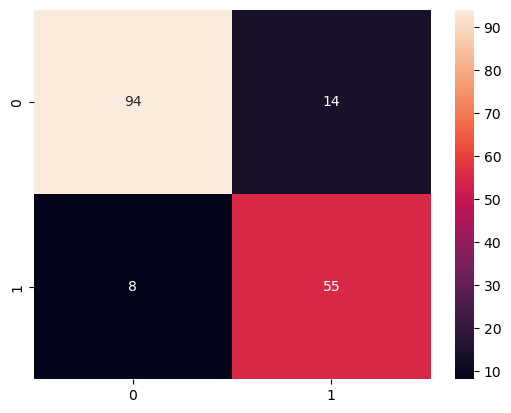

In [164]:
sns.heatmap(cm,annot=True)

# DECISION TREE

In [165]:
from sklearn.tree import DecisionTreeClassifier
decision_tree_model_model = DecisionTreeClassifier(random_state=42)
decision_tree_model_model.fit(X_train, y_train)
y_pred = decision_tree_model_model.predict(X_test)

In [166]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')


Accuracy: 0.8596491228070176


In [167]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[92 16]
 [ 8 55]]


<Axes: >

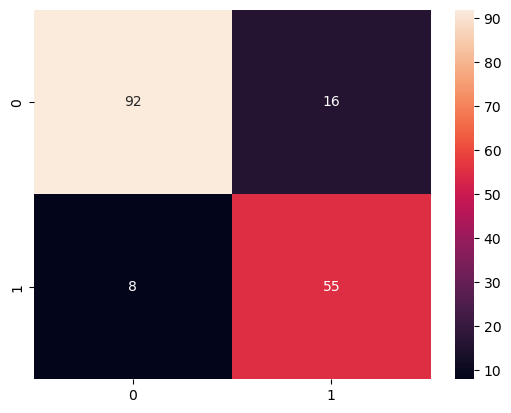

In [168]:
sns.heatmap(cm,annot=True)

In [169]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f1)

0.8208955223880596


In [170]:
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0], dtype=int64)

In [171]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print(precision)

0.7746478873239436


In [172]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred)
print(recall)

0.873015873015873


In [173]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
result_with_outliers["Decision Tree"]=[{"accuracy":accuracy_score(y_test,y_pred),"f1-score":f1,"precision":precision,"recall":recall,"mae":mean_absolute_error(y_test, y_pred),"mse":mean_squared_error(y_test, y_pred)}]


Mean Absolute Error (MAE): 0.14035087719298245
Mean Squared Error (MSE): 0.14035087719298245


# RESULTS WITH OUTLIERS

In [174]:
result_with_outliers

{'LogisticRegression': [{'accuracy': 0.9005847953216374,
   'f1-score': 0.8682170542635659,
   'precision': 0.8484848484848485,
   'recall': 0.8888888888888888,
   'mae': 0.09941520467836257,
   'mse': 0.09941520467836257}],
 'Random Forest': [{'accuracy': 0.8713450292397661,
   'f1-score': 0.8333333333333334,
   'precision': 0.7971014492753623,
   'recall': 0.873015873015873,
   'mae': 0.1286549707602339,
   'mse': 0.1286549707602339}],
 'Decision Tree': [{'accuracy': 0.8596491228070176,
   'f1-score': 0.8208955223880596,
   'precision': 0.7746478873239436,
   'recall': 0.873015873015873,
   'mae': 0.14035087719298245,
   'mse': 0.14035087719298245}]}

# DETECTING WITH OUTLIERS THROUGH BOXPLOT METHOD

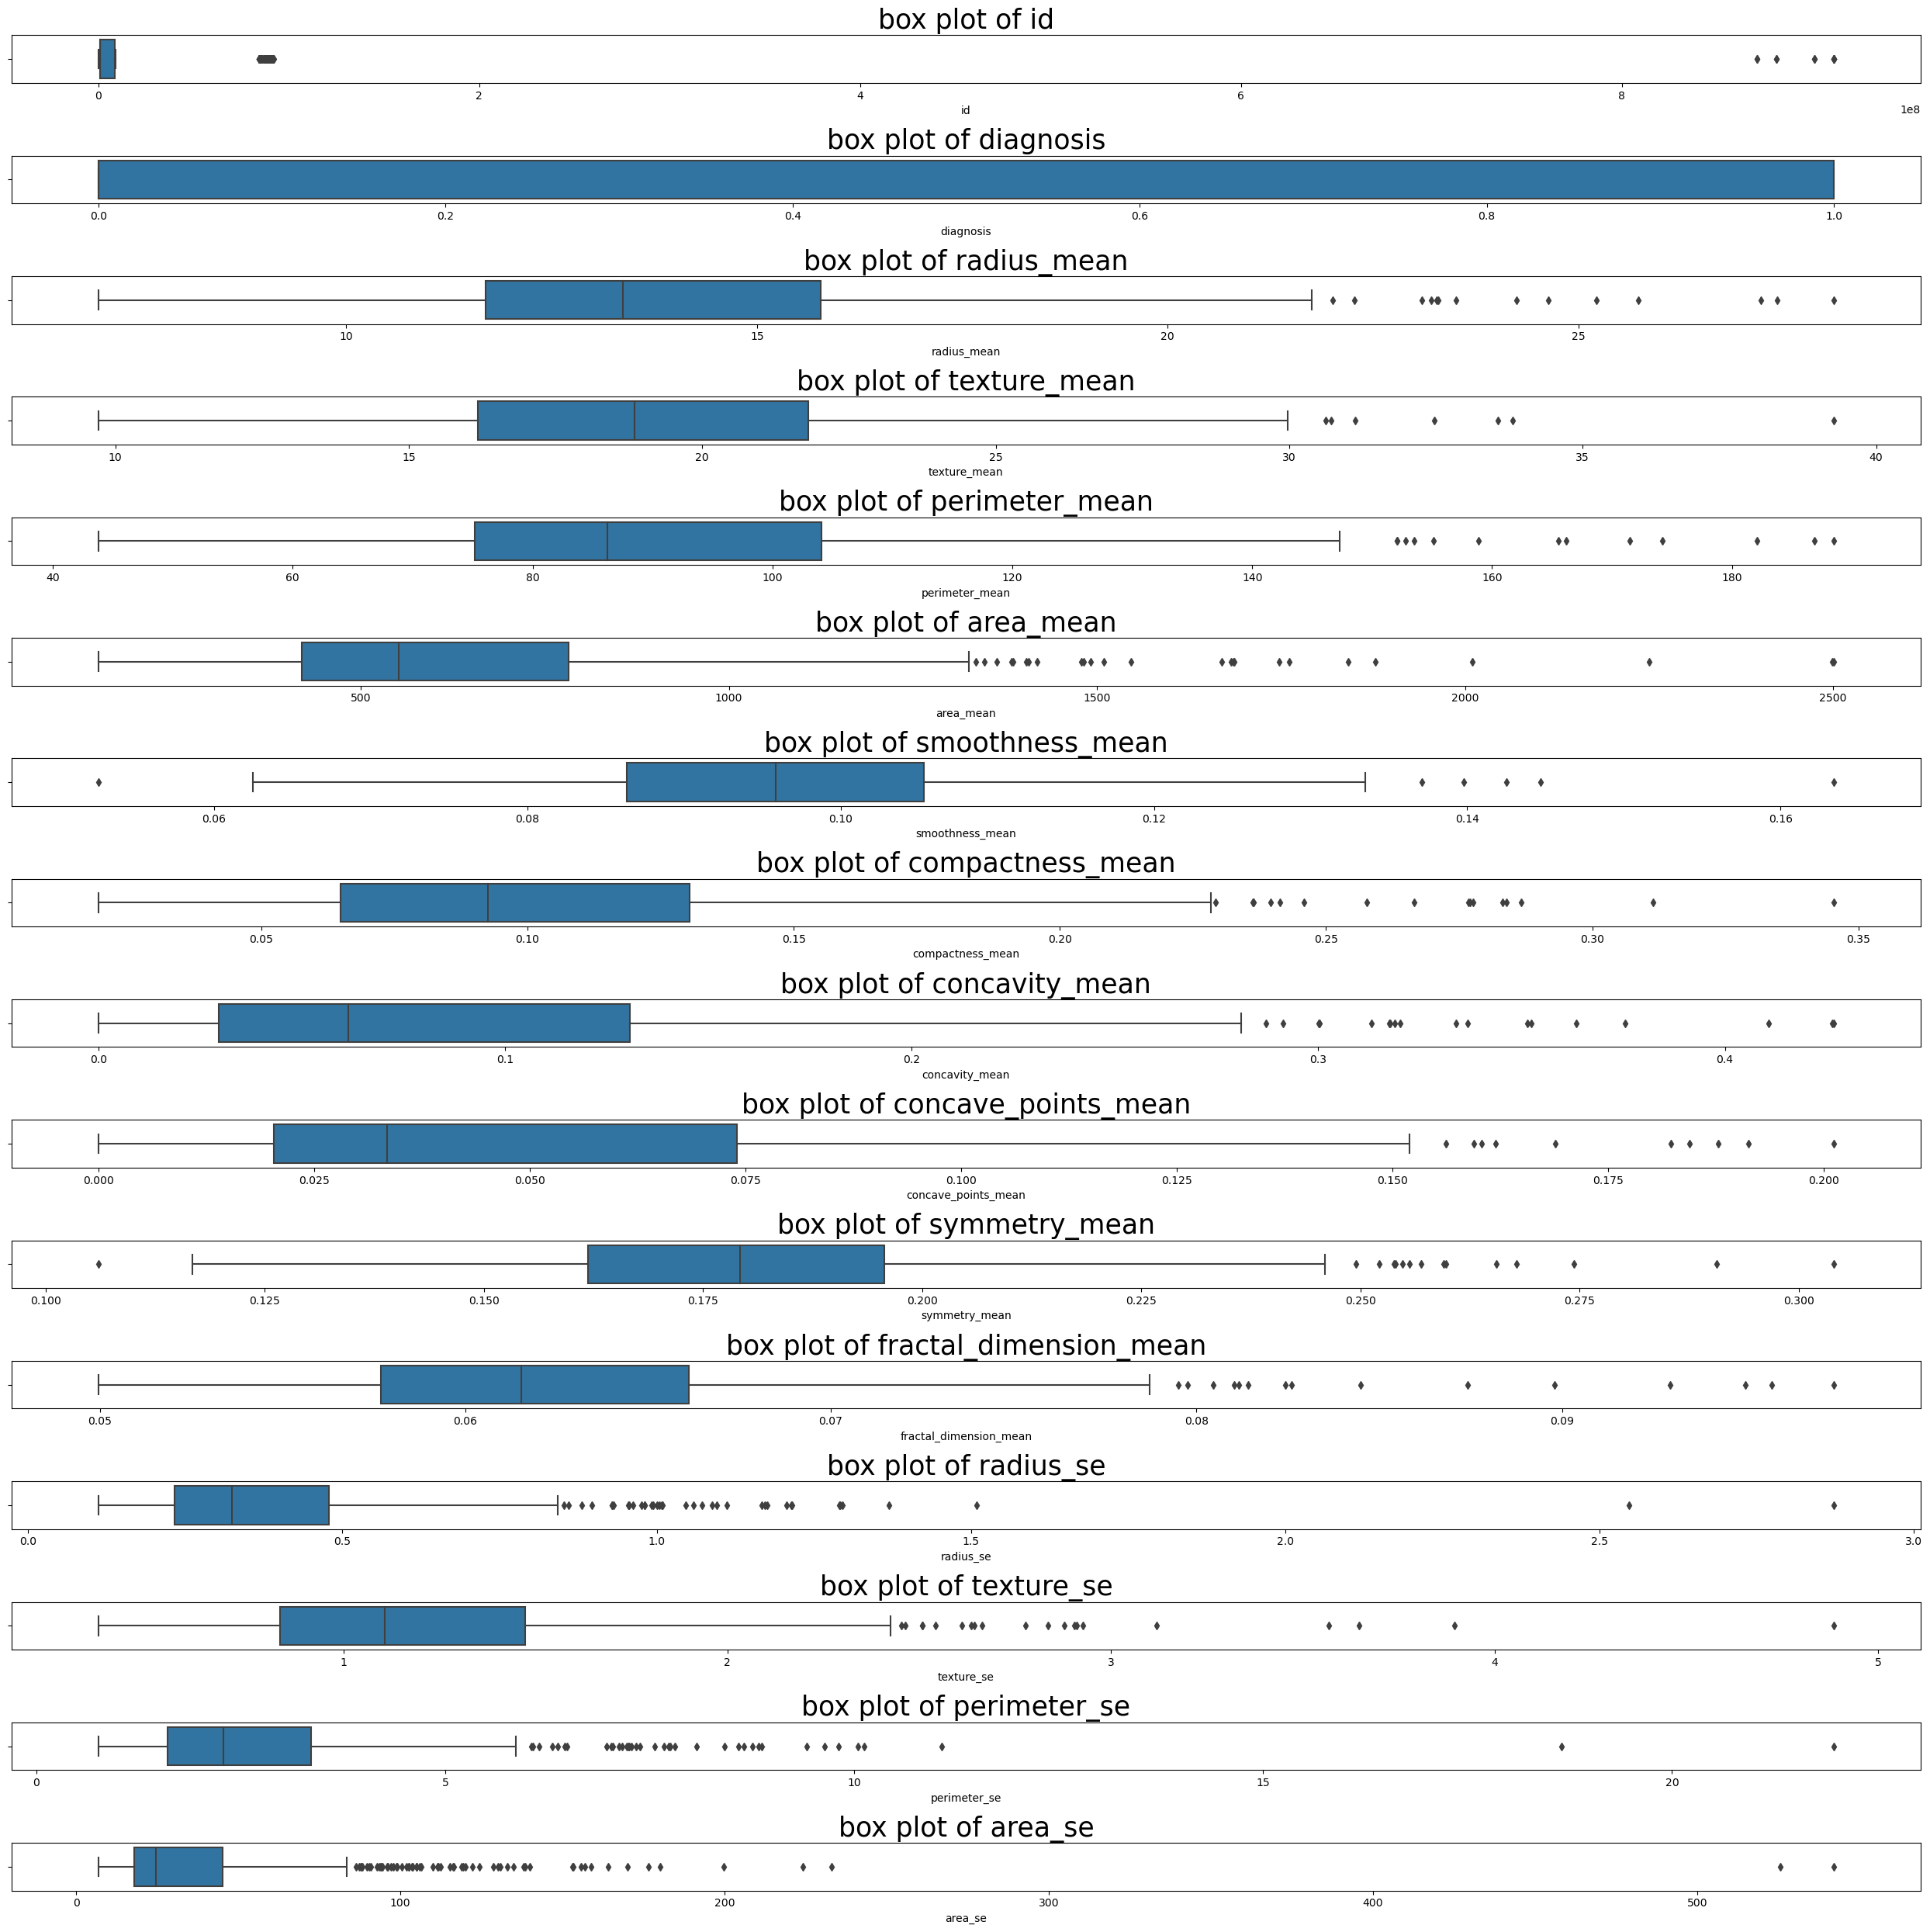

In [175]:
plt.figure(figsize=(25,25))
for i,feature in enumerate(df.columns[0:16]):
    plt.subplot(16,1,i+1)
    sns.boxplot(data=df,x=feature)
    plt.title(f'box plot of {feature}',fontsize=25)
plt.tight_layout()
plt.show()

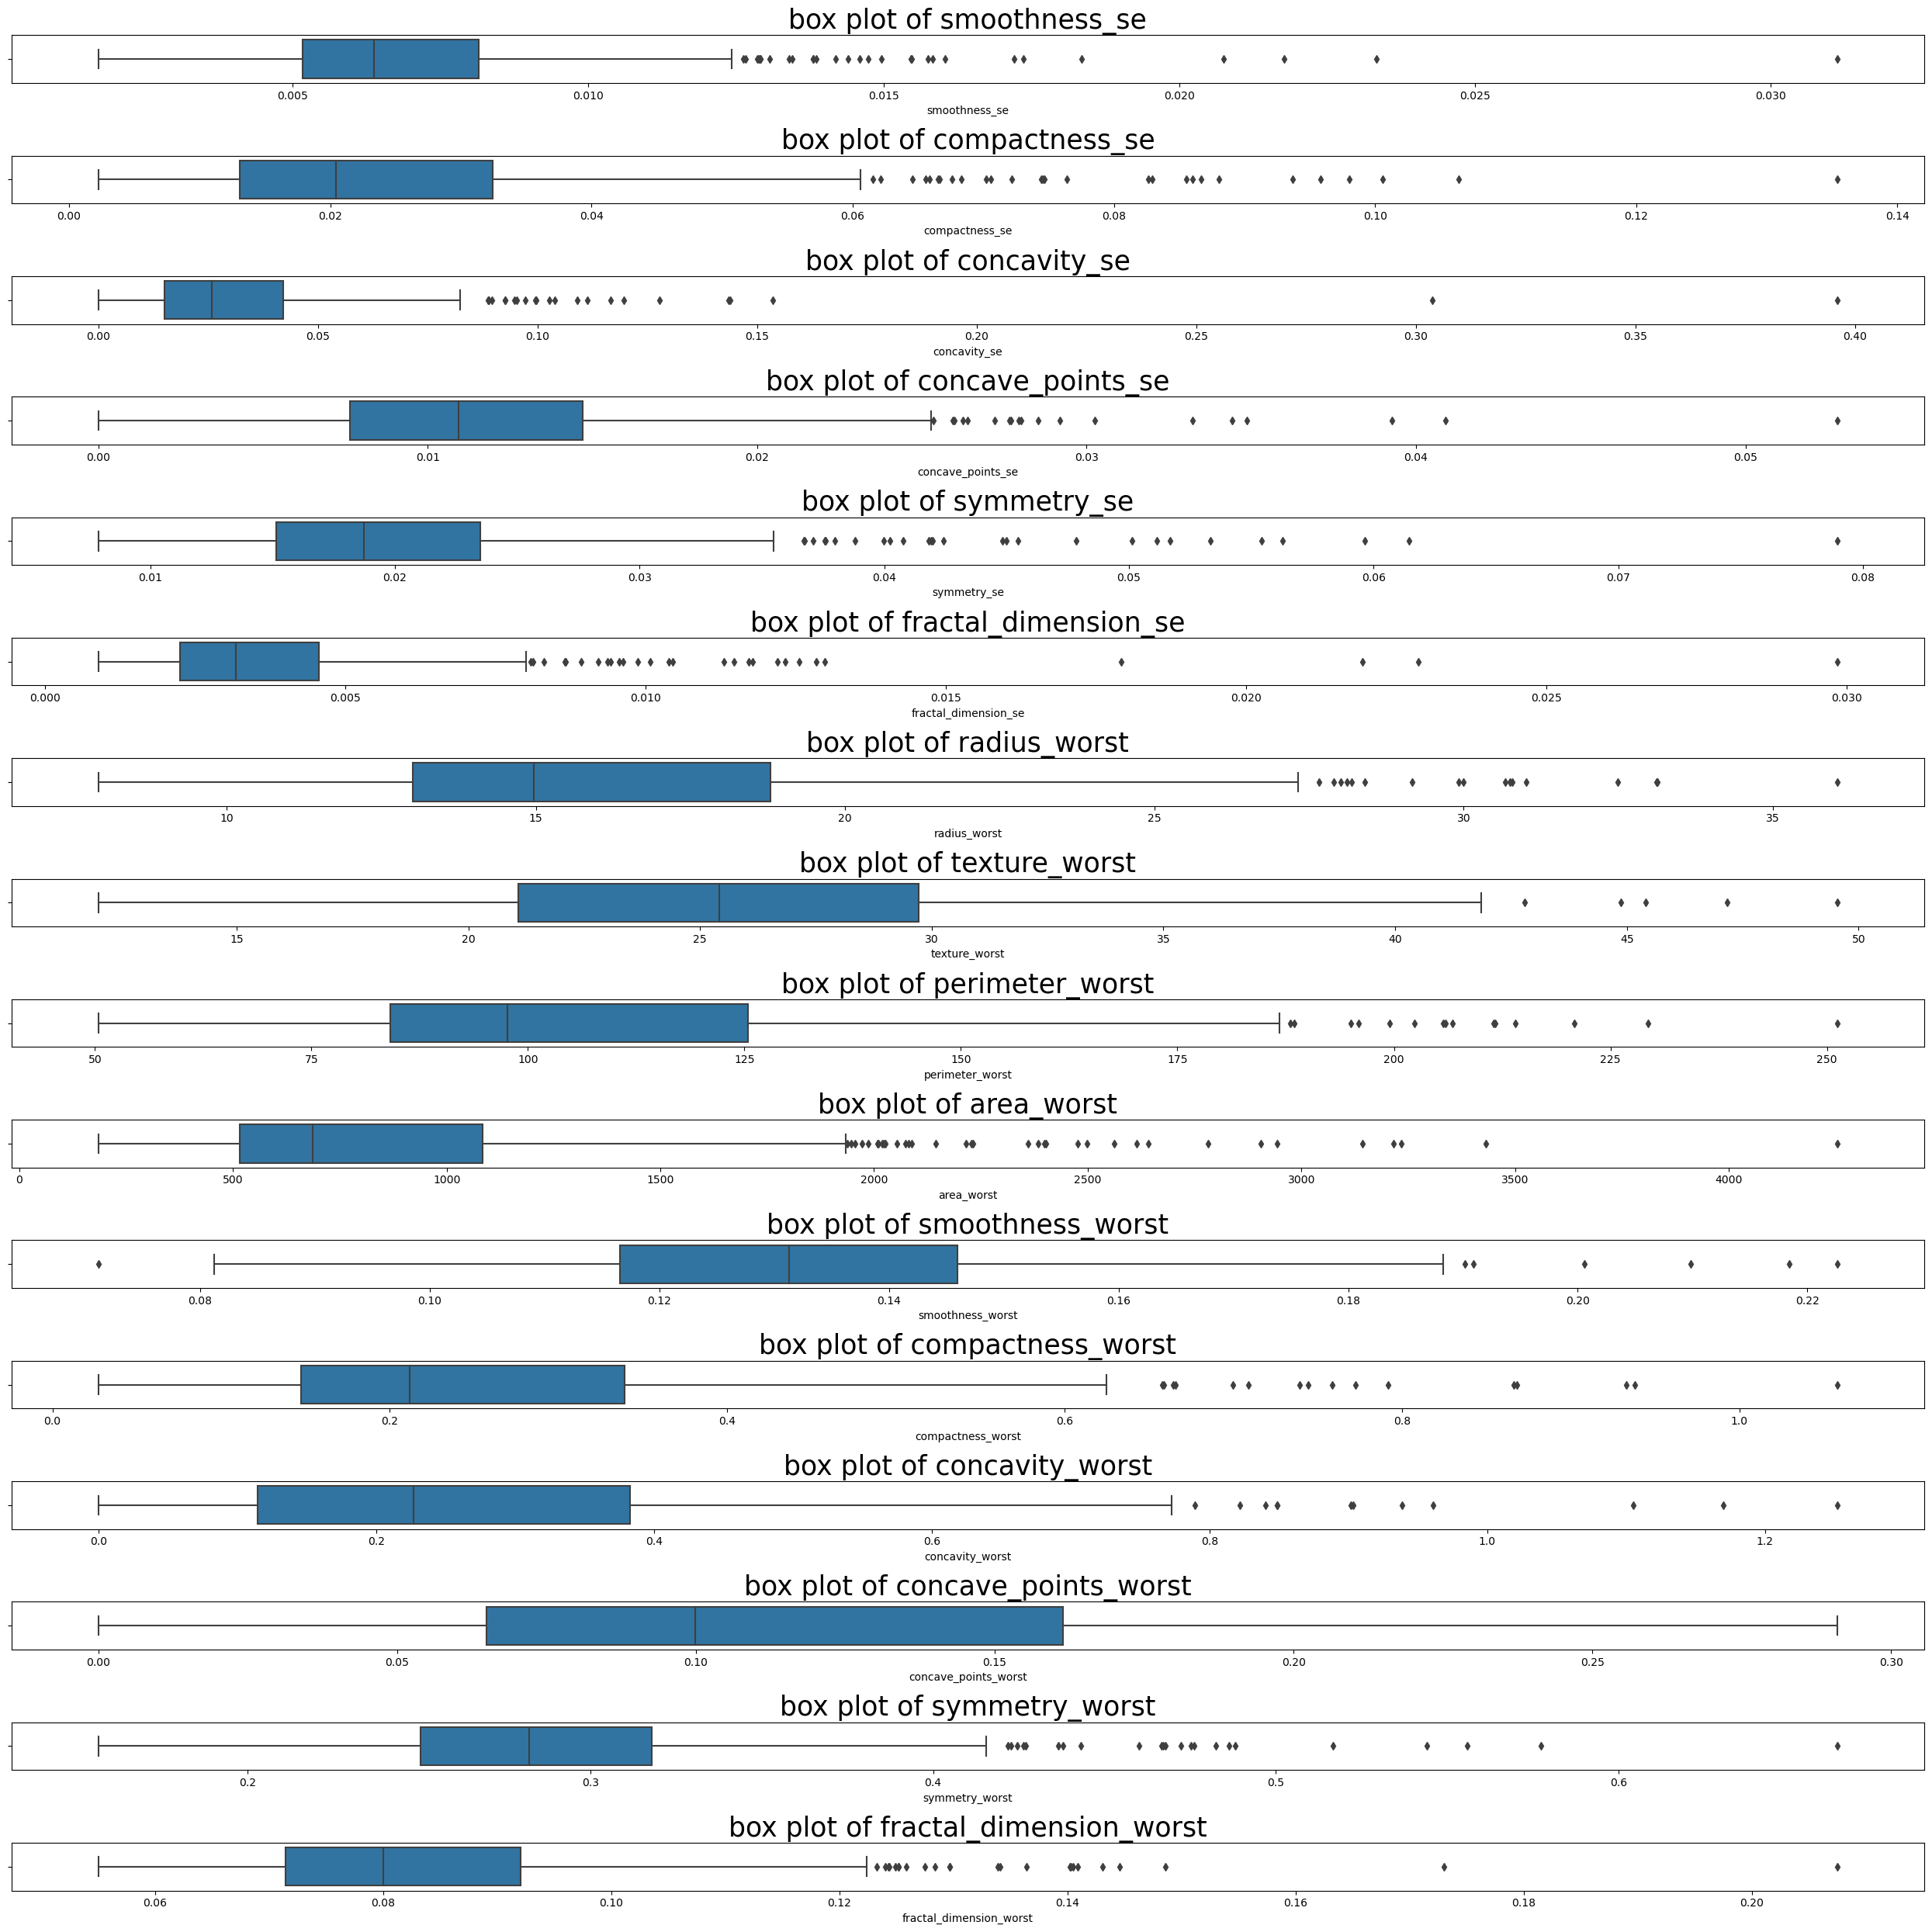

In [176]:
plt.figure(figsize=(25,25))
for i,feature in enumerate(df.columns[16:]):
    plt.subplot(16,1,i+1)
    sns.boxplot(data=df,x=feature)
    plt.title(f'box plot of {feature}',fontsize=25)
plt.tight_layout()
plt.show()

# REMOVING THE OUTLIERS

In [177]:
dic={}
for i,feature in enumerate(df.columns[2:]):
    upperlimit=df[feature].mean()+3*df[feature].std()
    lowerlimit=df[feature].mean()-3*df[feature].std()
    dic[feature]=[lowerlimit,upperlimit]
    

In [178]:
for value in dic:
    print(value," : ",dic[value])
    print()


radius_mean  :  [3.5551452612583176, 24.699438218530787]

texture_mean  :  [6.386541201650294, 32.19275581065199]

perimeter_mean  :  [19.07209027565095, 164.86597650818032]

area_mean  :  [-400.8532838542726, 1710.6314912356436]

smoothness_mean  :  [0.05416789678205825, 0.13855266560809995]

compactness_mean  :  [-0.05409728961475982, 0.26277925798031343]

concavity_mean  :  [-0.1503601103064573, 0.3279587419409037]

concave_points_mean  :  [-0.0674893887075135, 0.16532768044740806]

symmetry_mean  :  [0.0989190189092918, 0.2634047069255061]

fractal_dimension_mean  :  [0.041616521456574386, 0.08397869822708115]

radius_se  :  [-0.4267661427192966, 1.237110255197328]

texture_se  :  [-0.43809175078658047, 2.8717986049166333]

perimeter_se  :  [-3.199504435412788, 8.931622888839854]

area_se  :  [-96.13593746227932, 176.81009563451133]

smoothness_se  :  [-0.0019665749211481313, 0.01604853274188627]

compactness_se  :  [-0.028246399136961836, 0.07920267681710243]

concavity_se  :  [-0

In [179]:
df_withoutoutliers=pd.DataFrame(df)


In [180]:
for i,feature in enumerate(df.columns[2:]):
    df_withoutoutliers=df_withoutoutliers.drop(df_withoutoutliers[df_withoutoutliers[feature]<dic[feature][0]].index)
    df_withoutoutliers=df_withoutoutliers.drop(df_withoutoutliers[df_withoutoutliers[feature]>dic[feature][1]].index)
    
    

In [181]:
df_withoutoutliers

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.2,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.4,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,1,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.2,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
560,925292,0,14.05,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.04304,...,15.30,33.17,100.2,706.7,0.1241,0.2264,0.1326,0.1048,0.2250,0.08321
563,926125,1,20.92,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.14740,...,24.29,29.41,179.1,1819.0,0.1407,0.4186,0.6599,0.2542,0.2929,0.09873
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.45,26.40,166.1,2027.0,0.1410,0.2113,0.4107,0.2216,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.69,38.25,155.0,1731.0,0.1166,0.1922,0.3215,0.1628,0.2572,0.06637


# TESTING THE MODELS AND COMPARING THE RESULTS WITH THE MODELS TRAINED WITHOUT OUTLIERS

In [182]:
X=df_withoutoutliers.iloc[:,[2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]]
y=df_withoutoutliers.diagnosis.values

In [183]:
#Performing Testing and Training of data 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0)
sc=StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [184]:
n_components = 2
pca = PCA(n_components=n_components)
X_train=pca.fit_transform(X_train)
X_test=pca.fit_transform(X_test)

Text(0, 0.5, 'Second Principal Component')

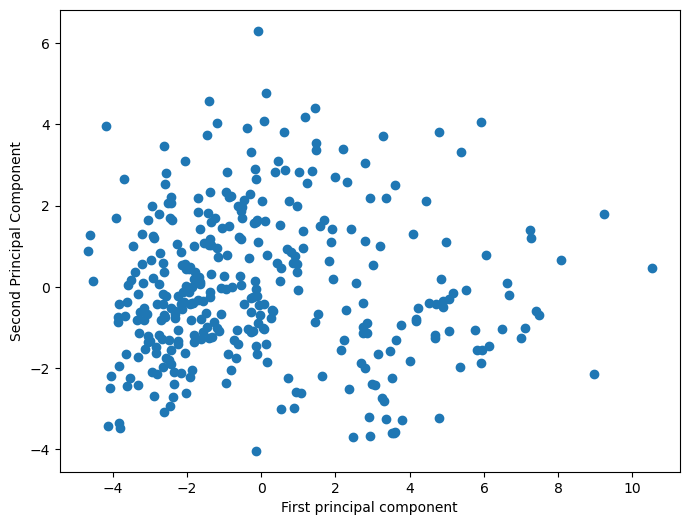

In [185]:
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0],X_train[:,1])
plt.xlabel('First principal component')
plt.ylabel('Second Principal Component')

In [186]:
X_train

array([[ 2.31837665e+00,  2.57433135e+00],
       [ 6.49100281e+00, -1.04784983e+00],
       [-2.35882167e+00, -2.09131378e+00],
       [ 5.93799790e+00, -1.56743592e+00],
       [-2.58113970e+00,  2.53356653e+00],
       [ 1.59096327e+00,  1.48650995e+00],
       [ 2.73831488e+00, -1.12824079e+00],
       [ 3.77825137e+00, -9.49726765e-01],
       [ 4.88487743e+00, -5.06501426e-01],
       [-3.86242037e+00, -7.53328697e-01],
       [-7.80851799e-01, -1.18241845e-02],
       [-2.47786194e+00, -1.81318584e+00],
       [-1.81919953e+00,  1.83547239e-01],
       [-1.56028936e+00, -3.43474623e-01],
       [ 3.41643037e-02,  2.11288370e+00],
       [ 5.38915646e-01, -2.99919449e+00],
       [-2.63548654e+00, -1.82739827e-01],
       [ 3.28679920e-01, -5.87215937e-01],
       [-1.16413985e+00,  7.35227270e-01],
       [ 2.14023187e+00, -1.56186640e+00],
       [-1.42173518e+00,  1.80693233e+00],
       [ 4.97287357e-01,  1.52676611e+00],
       [ 5.36906441e-01,  4.55694066e-01],
       [ 9.

In [187]:
X_test

array([[-2.29633085,  0.17808318],
       [-1.66177366,  2.66964138],
       [ 0.03279505,  0.95902502],
       [ 4.28663272,  2.9025794 ],
       [-1.03583179,  1.28200258],
       [-0.8265483 ,  0.37894035],
       [ 8.55190354, -2.86053933],
       [-2.21338847, -0.48406507],
       [-2.05992953, -0.85680318],
       [-0.79465226,  0.57822027],
       [ 0.4835247 ,  0.15738206],
       [-2.30288236, -1.34782508],
       [ 4.80545309, -3.34357211],
       [ 4.46781812, -0.19353548],
       [-0.40878711, -1.84241228],
       [ 0.04801154,  1.20940727],
       [-1.7239687 ,  0.17968002],
       [-3.28058449,  0.34095673],
       [-0.74510363, -1.96109061],
       [ 1.10045975,  1.44227512],
       [-1.3373335 ,  4.38553246],
       [-3.95588522, -0.31333719],
       [ 3.03395371, -0.19029184],
       [ 2.06952195, -0.87284864],
       [-1.77780476,  1.31201123],
       [ 5.79293642, -1.67779027],
       [ 3.11449006,  0.28230019],
       [-0.27472524,  2.46495569],
       [ 2.88714301,

In [188]:
explained_variance= pca.explained_variance_ratio_

In [189]:
explained_variance

array([0.42627197, 0.20861135])

In [190]:
np.sum(explained_variance)

0.6348833213710191

In [191]:
result_without_outliers={}

# LOGISTIC REGRESSION

In [192]:
#Logistric Regression
from sklearn.linear_model import LogisticRegression
classifier= LogisticRegression(random_state=0)
classifier.fit(X_train,y_train)

LogisticRegression(random_state=0)

In [193]:
#Prediction part
y_pred=classifier.predict(X_test)

In [194]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[96  6]
 [ 9 38]]


<Axes: >

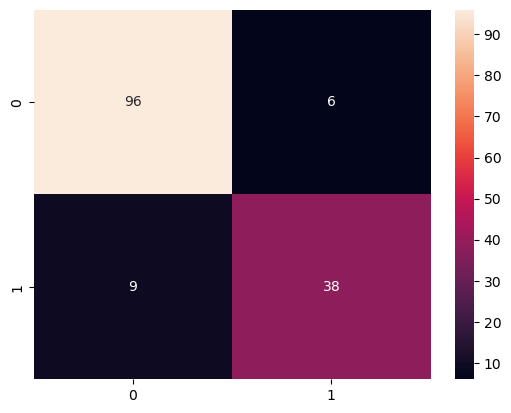

In [195]:
sns.heatmap(cm,annot=True)

In [196]:
y_pred

array([0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0], dtype=int64)

In [197]:
from sklearn.metrics import accuracy_score
print('Accuracy: ' +str(accuracy_score(y_test,y_pred)))

Accuracy: 0.8993288590604027


In [198]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f1)

0.8351648351648351


In [199]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print(precision)

0.8636363636363636


In [200]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred)
print(recall)

0.8085106382978723


In [201]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')


result_without_outliers["LogisticRegression"]=[{"accuracy":accuracy_score(y_test,y_pred),"f1-score":f1,"precision":precision,"recall":recall,"mae":mean_absolute_error(y_test, y_pred),"mse":mean_squared_error(y_test, y_pred)}]


Mean Absolute Error (MAE): 0.10067114093959731
Mean Squared Error (MSE): 0.10067114093959731


# RANDOM FOREST

In [202]:
from sklearn.ensemble import RandomForestClassifier
randomforest_model = RandomForestClassifier(n_estimators=60, random_state=42)
randomforest_model.fit(X_train, y_train)
y_pred = randomforest_model.predict(X_test)

In [203]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.8993288590604027


In [204]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f1)

0.8351648351648351


In [205]:
y_pred

array([0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0], dtype=int64)

In [206]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print(precision)

0.8636363636363636


In [207]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred)
print(recall)

0.8085106382978723


In [208]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')


result_without_outliers["Random Forest"]=[{"accuracy":accuracy_score(y_test,y_pred),"f1-score":f1,"precision":precision,"recall":recall,"mae":mean_absolute_error(y_test, y_pred),"mse":mean_squared_error(y_test, y_pred)}]



Mean Absolute Error (MAE): 0.10067114093959731
Mean Squared Error (MSE): 0.10067114093959731


In [209]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[96  6]
 [ 9 38]]


<Axes: >

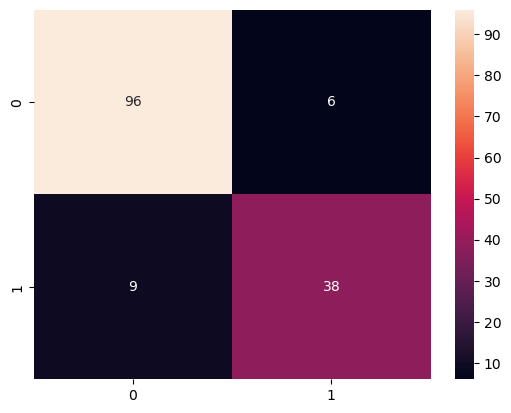

In [210]:
sns.heatmap(cm,annot=True)

# DECISION TREE

In [211]:
from sklearn.tree import DecisionTreeClassifier
decision_tree_model_model = DecisionTreeClassifier(random_state=42)
decision_tree_model_model.fit(X_train, y_train)
y_pred = decision_tree_model_model.predict(X_test)

In [212]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')


Accuracy: 0.9060402684563759


In [213]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[96  6]
 [ 8 39]]


<Axes: >

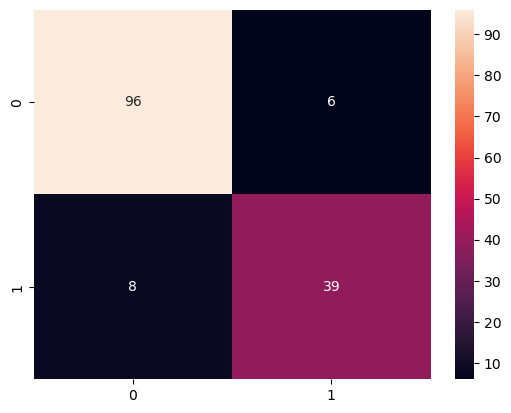

In [214]:
sns.heatmap(cm,annot=True)

In [215]:
y_pred

array([0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0], dtype=int64)

In [216]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f1)

0.8478260869565217


In [217]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print(precision)

0.8666666666666667


In [218]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred)
print(recall)

0.8297872340425532


In [219]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
result_without_outliers["Decision Tree"]=[{"accuracy":accuracy_score(y_test,y_pred),"f1-score":f1,"precision":precision,"recall":recall,"mae":mean_absolute_error(y_test, y_pred),"mse":mean_squared_error(y_test, y_pred)}]


Mean Absolute Error (MAE): 0.09395973154362416
Mean Squared Error (MSE): 0.09395973154362416


# RESULTS WITHOUT OUTLIERS

In [220]:
result_without_outliers

{'LogisticRegression': [{'accuracy': 0.8993288590604027,
   'f1-score': 0.8351648351648351,
   'precision': 0.8636363636363636,
   'recall': 0.8085106382978723,
   'mae': 0.10067114093959731,
   'mse': 0.10067114093959731}],
 'Random Forest': [{'accuracy': 0.8993288590604027,
   'f1-score': 0.8351648351648351,
   'precision': 0.8636363636363636,
   'recall': 0.8085106382978723,
   'mae': 0.10067114093959731,
   'mse': 0.10067114093959731}],
 'Decision Tree': [{'accuracy': 0.9060402684563759,
   'f1-score': 0.8478260869565217,
   'precision': 0.8666666666666667,
   'recall': 0.8297872340425532,
   'mae': 0.09395973154362416,
   'mse': 0.09395973154362416}]}

# The decision to remove outliers depends on the specific goals of my analysis and the characteristics of the  dataset. The implications may be as follows 

*Before Removing Outliers:*
- PC1 explained variance: 45.71%
- PC2 explained variance: 17.84%

*After Removing Outliers:*
- PC1 explained variance: 42.63%
- PC2 explained variance: 20.86%

Here are some considerations:

1. *Reduction in Variability:*
   - Removing outliers has led to a reduction in the explained variance for PC1, indicating that some variability associated with the first principal component was attributed to outliers. This reduction might be desirable if those outliers were noise or anomalies not representative of the underlying patterns in the data.

2. *Increased Variability in PC2:*
   - The explained variance for PC2 increased after removing outliers. This suggests that without the influence of outliers, the second principal component captures more of the total variance. If capturing more nuanced patterns in the data is important, this could be beneficial.This maybe very important for diagnosis of malignancy of cancer especially initial or early diagnosis for saving patients life.

3. *Balancing Act:*
   - The decision to remove outliers involves a balancing act. While removing outliers might improve the performance of certain algorithms or analyses, it's crucial to assess the potential impact on the overall representativeness of the data.

In summary and conclusion the decision to remove outliers depends on our specific objectives.

The nuanced patterns  in breast cancer can be very useful tool in terms of:

1)Improved  accuracy of diagnosis as early detection,subtle changes in the tumor is imperative in the  early start of treatment 

2)It helps the doctors to understand the type or subtype of the cancer,thereby initiate proper treatment modality for the patient 

3)Such nuanced patterns help in predicting the treatment modalities

4)Help the doctor in identification of Biomarkers i.e understand the cancer at the molecular level

5)These patterns are useful tools for ongoing research and helpful in discovery of new tools and therapies for better patient survival.